In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement du dataSet

In [3]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

df = pd.read_csv('dataset_reseau.csv')
df = df.copy()

# Affichage 

In [4]:
df.head()

,machine_id,os_type,duree_connexion,nombre_requetes,volume_donnees,statut_connexion
0,M1381,linux,124.841713,80,464.209300,success
1,M996,linux,203.399243,212,696.590874,Succes
2,M1411,macos,71.099503,213,430.462099,Success
3,M1448,windows,150.118079,216,341.491727,Fail
4,M1448,Andriod,182.837035,79,259.873768,Succes


In [7]:
df.tail()

,machine_id,os_type,duree_connexion,nombre_requetes,volume_donnees,statut_connexion
10195,M1331,MacOS,152.549519,280,519.291287,fail
10196,M830,macos,78.707837,154,748.516228,success
10197,M8,linux,109.976522,197,530.399940,Succes
10198,M1248,windows,105.207239,250,684.211355,Success
10199,M1275,Linus,154.154944,153,366.478292,Succes


# Nombre de ligne et colonne

In [8]:
df.shape

(10200, 6)

# Type de variable

In [9]:
df.dtypes

machine_id              str
os_type                 str
duree_connexion     float64
nombre_requetes       int64
volume_donnees      float64
statut_connexion        str
dtype: object

In [10]:
df.describe()

,duree_connexion,nombre_requetes,volume_donnees
count,9667.000000,10200.000000,9699.000000
mean,137.750628,199.042451,573.192602
std,125.556422,60.617558,557.366581
min,-25.753534,-24.000000,-43.984643
25%,93.851389,157.000000,399.976673
50%,120.775692,200.000000,502.638632
75%,149.055586,240.000000,608.036373
max,1197.000000,407.000000,5978.000000


# Observation du dataset

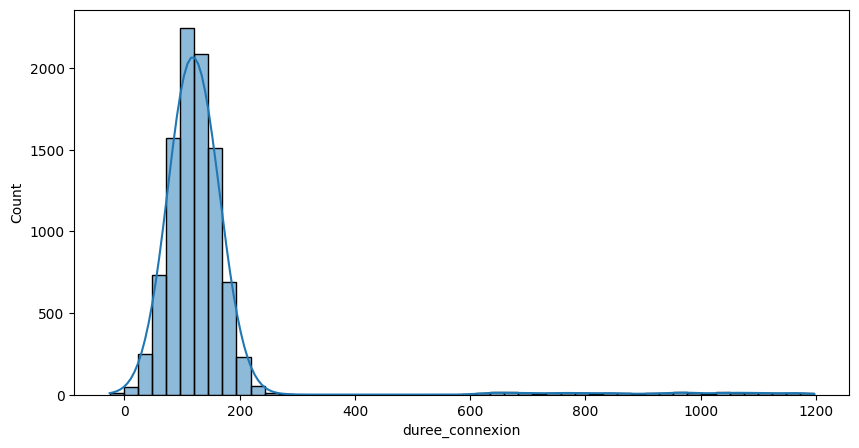

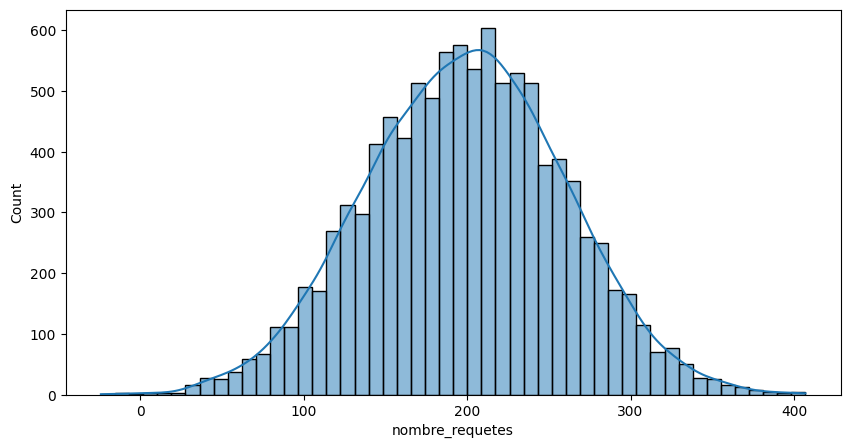

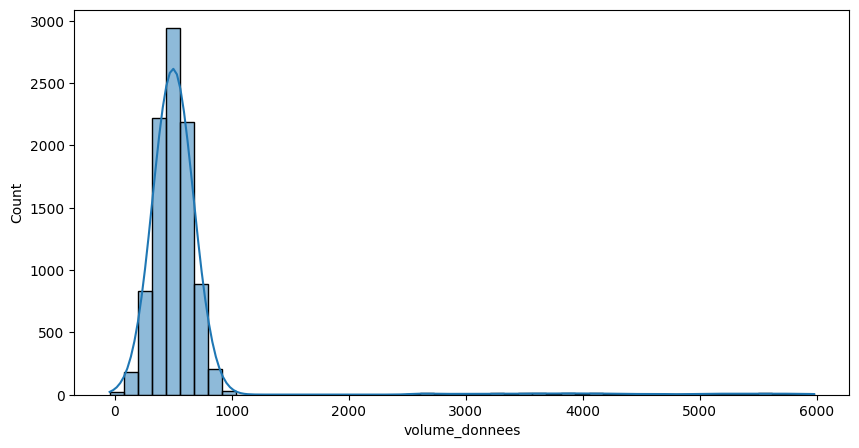

In [17]:
for col in df.select_dtypes(include=['int', 'float']):
    plt.figure(figsize=(10, 5))
    
    sns.histplot(
        data=df[col],
        kde=True,
        bins=50, 
        cbar=True
    )

<Figure size 1000x500 with 0 Axes>

/tmp/ipykernel_44651/1576730110.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


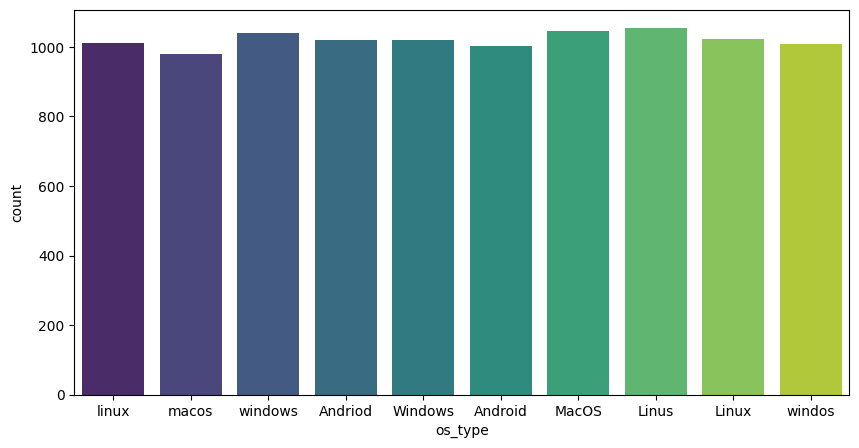

/tmp/ipykernel_44651/1576730110.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


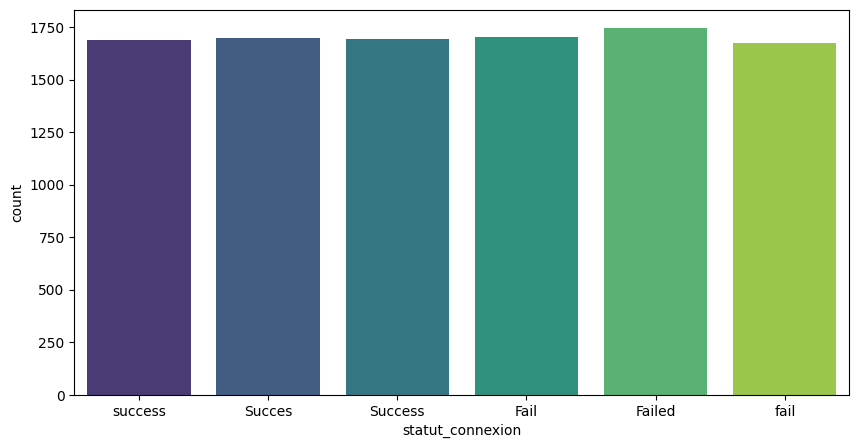

In [23]:
for col in df.select_dtypes('str'):
    plt.figure(figsize=(10,5))

    if col != 'machine_id':
        sns.countplot(
            x=df[col],
            palette='viridis'
        )

    plt.show()

# Detection d'anomalie

## observer les valeurs manquantes

In [27]:
df.isna().sum()

machine_id            0
os_type               0
duree_connexion     533
nombre_requetes       0
volume_donnees      501
statut_connexion      0
dtype: int64

In [31]:
(df.isna().sum() / df.shape[0]) * 100

machine_id          0.000000
os_type             0.000000
duree_connexion     5.225490
nombre_requetes     0.000000
volume_donnees      4.911765
statut_connexion    0.000000
dtype: float64

## Les Doublons

In [36]:
df.duplicated().value_counts()

False    10000
True       200
Name: count, dtype: int64

## Les irrégularités

- **os_type**
    - Linux, linux, linus
    - windows, Windows, windos
    - macos, MacOS
    - Android, Andriod
- **statut_connexion**
    - success, Succes, Success
    - Failed, fail, Fail